# 01-2. 전처리와 예측 문제 설계

01-1 노트북의 진단 결과를 실제 데이터 정리에 반영하고, **무엇을, 언제, 어떤 정보로 예측할지**와 **어떻게 공정하게 평가할지**를 정합니다.
보고서 **1-5(전처리)**와 **2-1~2-2(예측 문제·평가 방법)**의 근거 자료입니다.

이 노트북을 실행하면 모델링에 쓸 정리된 데이터가 `data/processed/`에 저장됩니다.

## 0. 준비

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

DATA_PATH = Path("../data/raw/okm_augumented_2021.csv")
OUT_DATA = Path("../data/processed"); OUT_DATA.mkdir(parents=True, exist_ok=True)
FIG_DIR = Path("../outputs/figures"); TAB_DIR = Path("../outputs/tables")

def save_fig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")

def save_table(df, name):
    df.to_csv(TAB_DIR / f"{name}.csv", encoding="utf-8-sig")

P = ["15분", "30분", "45분", "60분"]
MINUTE = {"15분": 0, "30분": 15, "45분": 30, "60분": 45}
WD = ["월", "화", "수", "목", "금", "토", "일"]

## 1. 진단 결과를 반영해 데이터 정리하기

01-1 노트북에서 정한 처리 방침을 순서대로 적용합니다.

| 순서 | 처리 | 이유 |
|---|---|---|
| 1 | 시각은 `시간` 열 대신 **하루 안의 행 순서**로 매김 | 7/13·7/15의 `시간` 열이 망가져 있음 (다른 날은 두 방법이 같음) |
| 2 | **7/1 이후만** 사용 | 1~6월은 62%가 다른 날을 복사한 기록 |
| 3 | 1시간 1행 → **15분 1행**으로 펼침 | 한전 요금이 15분 단위 |
| 4 | 7/13·7/15의 전력은 빈 값 | 행 순서가 섞여 몇 시 값인지 알 수 없음 |
| 5 | 전력 0은 빈 값 | 계측 중단 (8/28~29) |
| 6 | 7/28·7/30은 '정답으로 쓰지 않음' 표시 | 두 날의 전력 기록이 똑같아 하나는 복사본. 어느 쪽이 진짜인지 알 수 없음 |
| 7 | `평균`, `공장인원` 제거 | 정답(전력)으로 계산된 값 |

In [2]:
raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
raw["date"] = pd.to_datetime(raw["날짜"].astype(str), format="%Y%m%d")
raw["hour"] = raw.groupby("date").cumcount()                                   # 1. 행 순서로 시각
ok_days = raw["시간"].between(0, 23)
assert (raw.loc[ok_days, "hour"] == raw.loc[ok_days, "시간"]).all()            #    정상인 날은 시간 열과 같은지 확인

hourly = raw[raw["date"] >= "2021-07-01"].drop(columns=["평균", "공장인원", "날짜", "시간"])   # 2·7

slots = hourly.melt(id_vars=[c for c in hourly.columns if c not in P], value_vars=P,
                    var_name="칸", value_name="전력")                                     # 3.
slots["ts"] = slots["date"] + pd.to_timedelta(slots["hour"], "h") + pd.to_timedelta(slots["칸"].map(MINUTE), "m")
slots = slots.sort_values("ts").set_index("ts").drop(columns=["칸"])
slots["전력"] = slots["전력"].astype(float)

broken = slots["date"].isin(pd.to_datetime(["2021-07-13", "2021-07-15"]))
slots.loc[broken, "전력"] = np.nan                                                        # 4.
zero = slots["전력"] == 0
slots.loc[zero, "전력"] = np.nan                                                          # 5.
slots["정답사용"] = slots["전력"].notna() & ~slots["date"].isin(pd.to_datetime(["2021-07-28", "2021-07-30"]))  # 6. 7/28·7/30은 어느 쪽이 복사본인지 몰라 정답(평가 대상)에서 뺌

assert slots.index.is_unique and (slots.index.to_series().diff().dropna() == pd.Timedelta("15min")).all()
print(f"15분 칸 {len(slots):,}개 ({slots['date'].nunique()}일)")
print(f"  빈 값: 시간 순서 오류 {broken.sum()}칸, 계측 중단(0) {zero.sum()}칸")
print(f"  정답으로 쓰는 칸: {slots['정답사용'].sum():,}개")

15분 칸 7,296개 (76일)
  빈 값: 시간 순서 오류 192칸, 계측 중단(0) 74칸
  정답으로 쓰는 칸: 6,838개


## 2. '하루 종류'와 가동 계획 만들기

01-1 노트북에서 **전력은 '오늘이 어떤 날인가 + 지금 몇 시인가'로 대부분 정해진다**는 것을 확인했습니다.
그런데 쉬는 날은 공휴일 달력과 다릅니다(하계 휴무, 8/16 가동).
그래서 공휴일 달력 대신 **ERP 생산계획**으로 하루 종류를 정합니다.

- **가동일**: 그날 생산량 합계가 0보다 큼
- **하루 종류**: 평일 가동 / 토요일(오전까지 가동) / 휴일(일요일·휴무)
- **전날 가동 여부**: 전날 가동했으면 자정을 넘겨 야간 근무가 이어집니다(월요일 새벽이 꺼져 있는 이유).

> **가정**: 생산계획(생산량 열)은 ERP에 미리 입력되므로 **예측하는 시점(전날)에 알 수 있다**고 봅니다.
> 가이드북도 이 변수를 '해당 시점에 **생산해야 할** 생산량'으로 정의합니다. 생산계획 없이 달력만 쓸 때와의 비교는 02-2 노트북 1-3에서 합니다.
> 다만 시간별 생산량이 실제 가동과 거의 정확히 맞물려 있어, 계획이 아니라 실적일 가능성도 있습니다. 이 경우 하루 앞 예측의 정확도는 실제보다 좋게 나온 것일 수 있으며, 보고서의 한계로 밝힙니다.

In [3]:
day = hourly.groupby("date").agg(일생산량=("생산량", "sum"))
day["요일"] = day.index.dayofweek
day["가동일"] = day["일생산량"] > 0
day["하루종류"] = np.select([~day["가동일"], day["요일"] == 5], ["휴일", "토요일"], "평일가동")
day["전날가동"] = day["가동일"].shift(1, fill_value=True)     # 7/1의 '전날 가동'을 정하려고 6/30 원자료를 확인함 (가동일)
assert raw.loc[raw["date"] == "2021-06-30", "생산량"].sum() > 0

# 7/13·7/15는 생산량 기록도 0으로 남아 있지만 실제로는 평일 가동일 (전력이 평일 수준) → 평일 가동일로 바로잡음
fix = pd.to_datetime(["2021-07-13", "2021-07-15"])
print("7/13·7/15 일 생산량:", day.loc[fix, "일생산량"].tolist(),
      "| 일 최대 전력:", hourly[hourly["date"].isin(fix)].groupby("date")[P].max().max(axis=1).tolist())
day.loc[fix, ["가동일", "하루종류"]] = [True, "평일가동"]
day["전날가동"] = day["가동일"].shift(1, fill_value=True)

check = pd.crosstab(day["요일"].map(lambda i: WD[i]), day["하루종류"]).reindex(WD)
save_table(check, "t07_요일별_하루종류")
check

7/13·7/15 일 생산량: [0, 0] | 일 최대 전력: [190, 202]


하루종류,토요일,평일가동,휴일
요일,,,
월,0,10,1
화,0,10,1
수,0,9,1
목,0,10,1
금,0,10,1
토,9,0,2
일,0,0,11


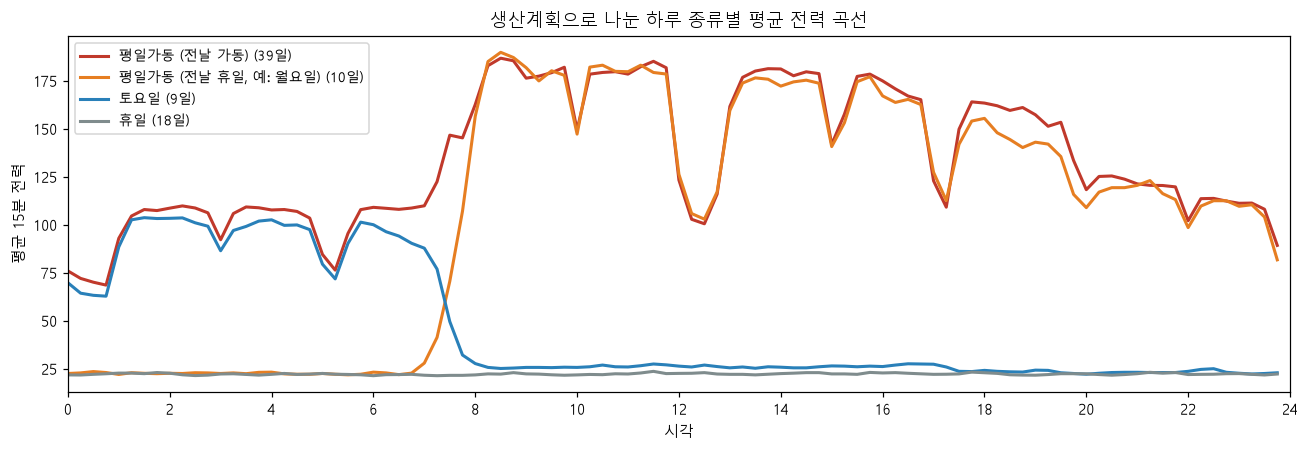

In [4]:
# 하루 종류별 하루 곡선이 잘 구분되는지 확인 (전날 가동 여부로 새벽 구간이 갈림)
slots = slots.join(day[["가동일", "하루종류", "전날가동", "일생산량"]], on="date")
slots["시각"] = slots.index.hour + slots.index.minute / 60
groups = {
    "평일가동 (전날 가동)": (slots["하루종류"] == "평일가동") & slots["전날가동"],
    "평일가동 (전날 휴일, 예: 월요일)": (slots["하루종류"] == "평일가동") & ~slots["전날가동"],
    "토요일": slots["하루종류"] == "토요일",
    "휴일": slots["하루종류"] == "휴일",
}
fig, ax = plt.subplots(figsize=(12, 4.2))
for (name, m), c in zip(groups.items(), ["#c0392b", "#e67e22", "#2980b9", "#7f8c8d"]):
    prof = slots[m & slots["정답사용"]].groupby("시각")["전력"].mean()
    ax.plot(prof.index, prof.values, color=c, lw=2, label=f"{name} ({slots[m]['date'].nunique()}일)")
ax.set_xticks(range(0, 25, 2)); ax.set_xlim(0, 24); ax.set_xlabel("시각"); ax.set_ylabel("평균 15분 전력")
ax.legend(fontsize=9); ax.set_title("생산계획으로 나눈 하루 종류별 평균 전력 곡선")
fig.tight_layout(); save_fig(fig, "f10_하루종류별_곡선"); plt.show()

**해석**: 생산계획으로 나눈 하루 종류 3가지 중 평일을 전날 가동 여부로 다시 나눈 네 가지 경우가 서로 전혀 다른 곡선을 그립니다.
특히 **'전날 가동했는가'**에 따라 같은 평일이라도 새벽(0~7시) 전력이 100 안팎과 20 수준으로 갈립니다.
→ 하루 앞 예측에서 **'내일의 하루 종류'와 '오늘 가동 여부'**가 가장 기본적인 입력이 됩니다.

## 3. 예측 문제 정의

### 3-1. 두 가지 예측
| | **주 예측: 하루 앞 예측** | **보조 예측: 1시간 앞 예측** |
|---|---|---|
| 언제 예측하나 | 매일 자정 직전 (전날 23:45 기록까지 보고) | 매 정시 (직전 15분 기록까지 보고) |
| 무엇을 예측하나 | 다음 날 15분 전력 **96칸 전체** | 다음 1시간의 15분 전력 **4칸** |
| 어디에 쓰나 | 생산 일정·설비 가동 시점 조정 (계획) | 당일 피크 경보 (대응) |
| 넘어야 할 기준 | 지난주 같은 시각 값 | 직전 15분 값 |

### 3-2. 예측할 때 쓸 수 있는 정보와 쓸 수 없는 정보
예측하는 순간에 **실제로 알 수 있는 정보만** 입력으로 씁니다. 미래 정보를 쓰면 성능이 부풀려집니다.

In [5]:
info = pd.DataFrame([
    ["달력 (요일, 시각)", "사용", "사용", "미리 알 수 있음"],
    ["생산계획 (하루 종류, 가동 여부, 시간별 계획량)", "사용", "사용", "ERP에 미리 입력된다고 가정"],
    ["과거 전력 기록", "전날 23:45까지", "직전 15분까지", "예측 시점까지 기록된 값만"],
    ["기온 등 날씨", "기본 모델에서 제외", "기본 모델에서 제외", "미래 실제 기온은 알 수 없음 (예보를 쓴다고 가정한 비교 실험만)"],
    ["전기요금(계절), 인건비", "제외", "제외", "월·시각과 같은 정보 → 비용 계산에 사용"],
    ["평균, 공장인원", "사용 금지", "사용 금지", "정답(전력)으로 계산된 값"],
], columns=["정보", "하루 앞 예측", "1시간 앞 예측", "이유"]).set_index("정보")
save_table(info, "t08_입력정보_사용여부")
info

,하루 앞 예측,1시간 앞 예측,이유
정보,,,
"달력 (요일, 시각)",사용,사용,미리 알 수 있음
"생산계획 (하루 종류, 가동 여부, 시간별 계획량)",사용,사용,ERP에 미리 입력된다고 가정
과거 전력 기록,전날 23:45까지,직전 15분까지,예측 시점까지 기록된 값만
기온 등 날씨,기본 모델에서 제외,기본 모델에서 제외,미래 실제 기온은 알 수 없음 (예보를 쓴다고 가정한 비교 실험만)
"전기요금(계절), 인건비",제외,제외,월·시각과 같은 정보 → 비용 계산에 사용
"평균, 공장인원",사용 금지,사용 금지,정답(전력)으로 계산된 값


## 4. 평가 방법 — 과거로 배우고 미래로 시험한다

무작위로 섞어서 나누면 **바로 옆 15분 값이 학습과 시험에 함께 들어가** 성능이 부풀려집니다(가이드북의 랜덤 포레스트 실습이 이렇게 나눔).
그래서 **시간 순서대로** 나눕니다.

- 시험 기간: 하계 휴무가 끝난 **8/9부터 9/14까지 5주**를 한 주씩 시험합니다.
- 각 시험 주마다 **그 이전의 모든 데이터로만 학습**합니다(시험 주가 뒤로 갈수록 학습 기간이 39일에서 67일로 늘어남, 표 9).
- 5주의 결과를 합쳐 최종 성능으로 봅니다. 한 주만 시험하면 그 주가 우연히 쉬웠는지 어려웠는지에 따라 결과가 흔들리기 때문입니다.

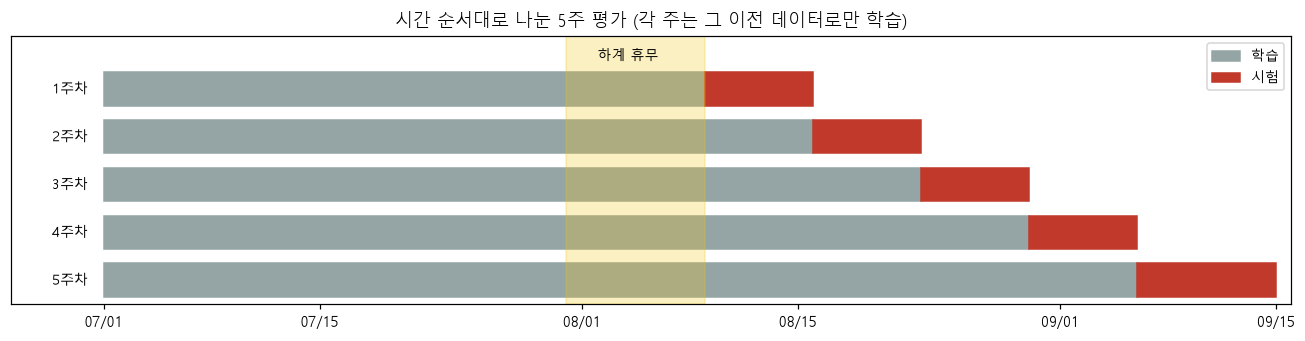

,시험 시작,시험 끝,학습 기간,학습 일수,시험 일수,시험 칸 수(정답)
1주차,2021-08-09,2021-08-15,07/01 ~ 08/08,39,7,672
2주차,2021-08-16,2021-08-22,07/01 ~ 08/15,46,7,672
3주차,2021-08-23,2021-08-29,07/01 ~ 08/22,53,7,600
4주차,2021-08-30,2021-09-05,07/01 ~ 08/29,60,7,672
5주차,2021-09-06,2021-09-14,07/01 ~ 09/05,67,9,862


In [6]:
test_starts = pd.to_datetime(["2021-08-09", "2021-08-16", "2021-08-23", "2021-08-30", "2021-09-06"])
test_ends = list(test_starts[1:] - pd.Timedelta(days=1)) + [pd.Timestamp("2021-09-14")]
folds = pd.DataFrame({"시험 시작": test_starts, "시험 끝": test_ends})
folds["학습 기간"] = "07/01 ~ " + (folds["시험 시작"] - pd.Timedelta(days=1)).dt.strftime("%m/%d")
folds["학습 일수"] = (folds["시험 시작"] - pd.Timestamp("2021-07-01")).dt.days
folds["시험 일수"] = (folds["시험 끝"] - folds["시험 시작"]).dt.days + 1
folds["시험 칸 수(정답)"] = [slots.loc[s:e + pd.Timedelta(hours=23, minutes=45), "정답사용"].sum() for s, e in zip(folds["시험 시작"], folds["시험 끝"])]
folds.index = [f"{i+1}주차" for i in range(len(folds))]
save_table(folds, "t09_평가_주차")

fig, ax = plt.subplots(figsize=(12, 3.2))
start = pd.Timestamp("2021-07-01")
for i, (s, e) in enumerate(zip(test_starts, test_ends)):
    y = len(test_starts) - 1 - i
    ax.add_patch(Rectangle((mdates.date2num(start), y + 0.15), mdates.date2num(s) - mdates.date2num(start), 0.7, color="#95a5a6"))
    ax.add_patch(Rectangle((mdates.date2num(s), y + 0.15), (e - s).days + 1, 0.7, color="#c0392b"))
    ax.text(mdates.date2num(start) - 1, y + 0.5, f"{i+1}주차", ha="right", va="center", fontsize=9)
ax.axvspan(mdates.date2num(pd.Timestamp("2021-07-31")), mdates.date2num(pd.Timestamp("2021-08-09")), color="#f1c40f", alpha=0.25)
ax.text(mdates.date2num(pd.Timestamp("2021-08-04")), len(test_starts) + 0.1, "하계 휴무", ha="center", fontsize=9)
ax.set_xlim(mdates.date2num(pd.Timestamp("2021-06-25")), mdates.date2num(pd.Timestamp("2021-09-16")))
ax.set_ylim(0, len(test_starts) + 0.6); ax.set_yticks([])
ax.xaxis_date(); ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
ax.legend(handles=[Rectangle((0, 0), 1, 1, color="#95a5a6"), Rectangle((0, 0), 1, 1, color="#c0392b")],
          labels=["학습", "시험"], loc="upper right", fontsize=9)
ax.set_title("시간 순서대로 나눈 5주 평가 (각 주는 그 이전 데이터로만 학습)")
fig.tight_layout(); save_fig(fig, "f11_평가방법"); plt.show()
folds

**평가 지표**
- **평균 절대오차(MAE)**: 예측이 실제와 평균적으로 얼마나 차이 나는지. 전력과 같은 단위라 이해하기 쉽습니다. *주 지표*
- **고부하 구간 MAE**: 실제 전력이 높은 구간(상위 10%)에서의 오차. 피크를 얼마나 잘 맞히는지 봅니다.
- **하루 최대 전력 오차**: 하루 중 가장 높은 값을 얼마나 맞히는지. 요금과 직결됩니다.
- **주별 MAE 범위**: 5주 중 가장 좋았던 주 ~ 가장 나빴던 주의 MAE. 결과가 주마다 얼마나 흔들리는지 봅니다.
- 휴일·야간처럼 전력이 낮은 구간에서는 비율 오차(MAPE)가 지나치게 커지고, 전기요금도 전력의 절대값으로 매겨지므로 비율 오차는 쓰지 않습니다.

피크 경보 성능(놓친 피크, 헛경보)은 다음 단계(02-3 노트북)에서 다룹니다.

## 5. 정리된 데이터 저장

In [7]:
keep = ["date", "hour", "시각", "전력", "정답사용", "생산량", "일생산량", "가동일", "하루종류", "전날가동",
        "기온", "풍속", "습도", "강수량", "전기요금(계절)", "인건비"]
out = slots[keep].copy()
out.index.name = "ts"
out.to_csv(OUT_DATA / "slots_15min.csv", encoding="utf-8-sig")
day.to_csv(OUT_DATA / "days.csv", encoding="utf-8-sig")
print("저장:", OUT_DATA / "slots_15min.csv", out.shape, "|", OUT_DATA / "days.csv", day.shape)
out.head()

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)
